# Génération de 3 classes de points
*  @param {number} nbPoints - nombre total de points à générer.
*  Chaque point a 3 caractéristiques : x, y, et type de classe  (0 pour la première classe, 1 pour la deuxième et 2 pour la troisième).

y_true :
[2 2 0 ... 0 2 1]
1/1 [==============================] - 0s 35ms/step
prediction A :
[0.00,1.00,0.00]
prédiction B :
[0.00,0.00,1.00]
prédiction C :
[0.66,0.00,0.34]


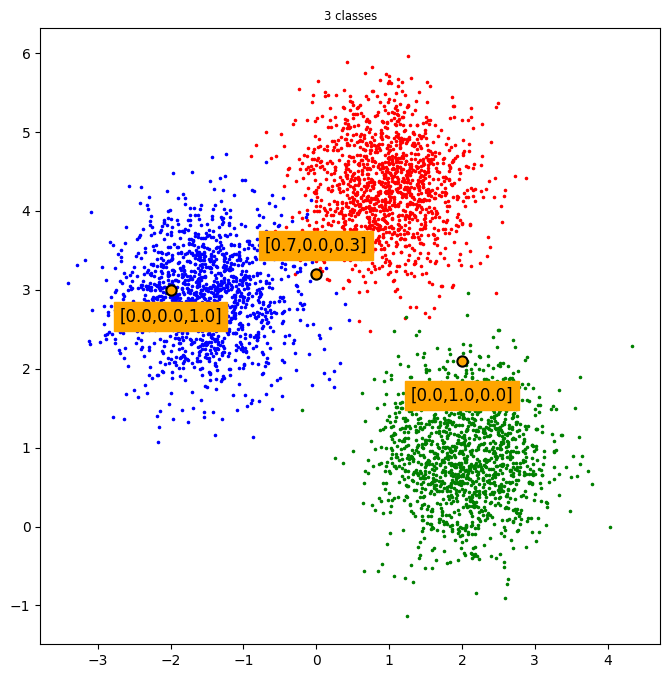

In [1]:
import matplotlib.pyplot as plt
from keras.models import Sequential 
from keras.layers import Activation, Dense 
from keras import initializers
from keras.optimizers import SGD, Adam
from keras.utils import to_categorical
import numpy as np 
#from sklearn.cluster import kmeans_plusplus
from sklearn.datasets import make_blobs

# Generate sample data
n_samples = 4000
n_components = 3

X, y_true = make_blobs(
    n_samples=n_samples, centers=n_components, cluster_std=0.60, random_state=0
)
#X = X[:, ::-1] # invertion des données
print('y_true :')
print(y_true)
#my_init = initializers.Zeros() 
my_init = initializers.Ones()
#my_init = initializers.RandomUniform(minval=0.0, maxval=1.0)
#normalizer = preprocessing.Normalization()
model=Sequential()
#pour La couche d'entrée, input_shape vaut : 2  (car on a 2 features: x et y), pas de normalisation nécessaire
model.add(Dense(units=128,input_shape=[2],activation= 'relu',kernel_initializer = my_init))

#La couche de sortie, units vaut 3 mais activation softmax
model.add(Dense(units=3, activation='softmax'))

#Création du réseau ("adam "alternatif à "sgd")
#opt = SGD(lr=0.01) #w = w - learning_rate * g
opt = Adam(learning_rate=0.01)
hist = model.compile(loss='categorical_crossentropy',optimizer=opt,  metrics=['accuracy'])
# entrée de dimension 2 (x, y)
entree = X
# y_true de dimension  3 (3 classes)
sortie = to_categorical(y_true) #Converts a class vector (integers) to binary class matrix.
# 0 >  0 0 0
# 1 >  1 0 0    vecteur (y_true) > matrice binaire (sortie)
# 2 >  0 1 0


#Entraînement du réseau xx passages
model.fit(x=entree,y=sortie,epochs=20,verbose =0)

#Print weights
#print("")
#print("Weights: \n")
#print(model.get_weights())

#Prediction
A= [[2,2.1]]
B= [[-2,3]]
C= [[0,3.2]]
Apred = model.predict(A)
Bpred = model.predict(B)
Cpred = model.predict(C)

#Affichage des prédictions
#print(model.predict(B))
#print(A[0][1])

print('prediction A :')
print(f"[{Apred[0][0]:.2f},{Apred[0][1]:.2f},{Apred[0][2]:.2f}]")

print('prédiction B :')
print(f"[{Bpred[0][0]:.2f},{Bpred[0][1]:.2f},{Bpred[0][2]:.2f}]")

print('prédiction C :')
print(f"[{Cpred[0][0]:.2f},{Cpred[0][1]:.2f},{Cpred[0][2]:.2f}]")

# Plot init seeds along side sample data
plt.figure(figsize=(8, 8))
plt.subplot(111)

#colors = ["#4EACC5", "#FF9C34", "#4E9A06"]
colors = ["red", "green", "blue"]

for k, col in enumerate(colors):# k index , col couleur
    cluster_data = (y_true == k)# cluster succession de valeurs vraies ou fausses
    plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=col, marker=".", s=10)# X[cluster_data, 0] prend les valeurs X[i,0] pour lesquelles cluster_data[i]=True
plt.scatter(A[0][0], A[0][1], marker="o",c='orange', s=55, edgecolor="k", lw=1.5)
plt.scatter(B[0][0], B[0][1], marker="o",c='orange', s=55, edgecolor="k", lw=1.5)
plt.scatter(C[0][0], C[0][1], marker="o",c='orange', s=55, edgecolor="k", lw=1.5)
plt.text(2, 1.6, f"[{Apred[0][0]:.1f},{Apred[0][1]:.1f},{Apred[0][2]:.1f}]", fontsize = 12, backgroundcolor ='orange', ha ='center', c ='black')
plt.text(-2, 2.6, f"[{Bpred[0][0]:.1f},{Bpred[0][1]:.1f},{Bpred[0][2]:.1f}]", fontsize = 12, backgroundcolor ='orange', ha ='center', c ='black')
plt.text(0, 3.5, f"[{Cpred[0][0]:.1f},{Cpred[0][1]:.1f},{Cpred[0][2]:.1f}]", fontsize = 12, backgroundcolor ='orange', ha ='center', c ='black')
#plt.scatter(centers_init[:, 0], centers_init[:, 1], c="b", s=50)
plt.title("3 classes", fontsize="small")

plt.show()


# Traçons les différents domaines ....

1954/1954 [==============================] - 2s 853us/step


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Domaines de décision ...'}>)

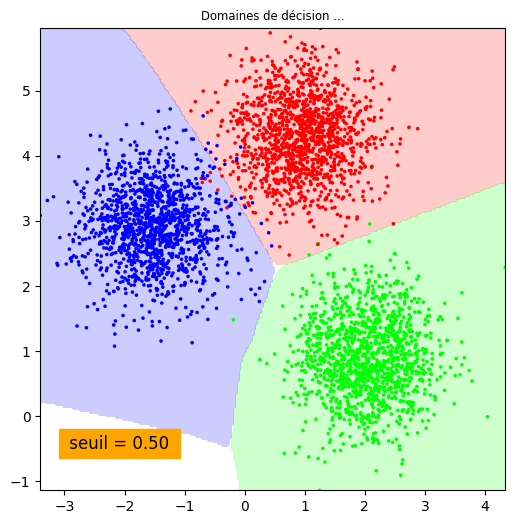

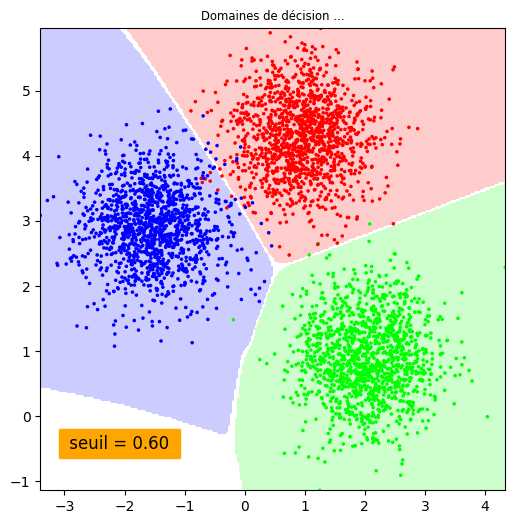

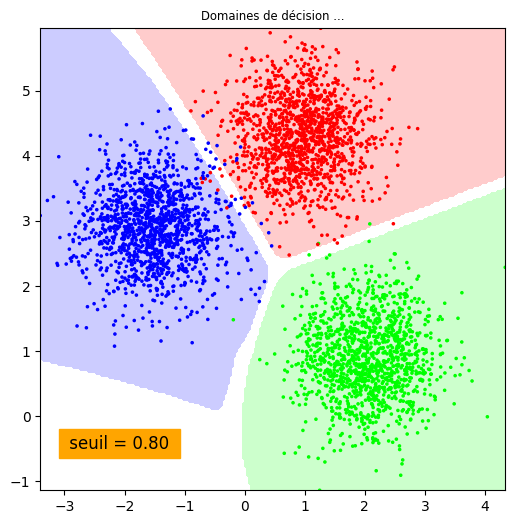

In [2]:
import matplotlib as mpl
def plot_decision_boundary2(X, y, model, steps=250,alpha=0.2,seuil=0.51):
    """
    Function to plot the decision boundary and data points of a model.
    Data points are colored based on their actual label.
    """
    #alpha = alpha
    colorT = (0, 0, 0.0,0.0)# tranparent
    color2 = [(1, 0, 0,alpha),(0, 1, 0,alpha),(0, 0, 1,alpha)]# les trois couleurs
    def C_map(coul):
        cmap = (mpl.colors.ListedColormap([colorT, coul]))
        #bounds = [0, 0.9, 1]
        #norm = mpl.colors.BoundaryNorm(bounds, cmap.N) 
        return cmap

    # Define region of interest by data limits
    xmin, xmax = X[:,0].min(), X[:,0].max()
    ymin, ymax = X[:,1].min(), X[:,1].max()
    steps = steps
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)

    # Make predictions across region of interest
    labels = model.predict(np.c_[xx.ravel(), yy.ravel()])
    fig = plt.figure(figsize=(6, 6))
    ax =plt.subplot(111)
    #fig, ax = plt.subplots()
    for i in range(0,3): 
        #labels1= labels[:,i]
        #print(labels1)
        # Plot decision boundary in region of interest
        z = labels[:,i].reshape(xx.shape)
        z = z > seuil #(seuil Threshold value)
        ax.contourf(xx, yy, z, cmap=C_map(color2[i]))
    plt.text(-3, -0.5, f" seuil = {seuil:.2f} ", fontsize = 12, backgroundcolor ='orange', ha ='left', c ='black')
    plt.title("Domaines de décision ...", fontsize="small")
    ax.scatter(X[:,0], X[:,1], c=y, lw=1,marker=".", s=10)
    
    return fig, ax

plot_decision_boundary2(entree, sortie, model, alpha=0.2, seuil=0.5)
plot_decision_boundary2(entree, sortie, model, alpha=0.2,seuil = 0.6)
plot_decision_boundary2(entree, sortie, model, alpha=0.2,seuil = 0.8)